In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

In [ ]:
model = models.Sequential()

# First Convolution Layer
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Flatten Layer
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(128, activation='relu'))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9609 - loss: 0.1051 - val_accuracy: 0.9198 - val_loss: 0.2623
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.9696 - loss: 0.0820 - val_accuracy: 0.9230 - val_loss: 0.2600
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 36ms/step - accuracy: 0.9765 - loss: 0.0635 - val_accuracy: 0.9156 - val_loss: 0.3263
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9800 - loss: 0.0536 - val_accuracy: 0.9187 - val_loss: 0.3193
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.9839 - loss: 0.0441 - val_accuracy: 0.9179 - val_loss: 0.3772


In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9179 - loss: 0.2360
Test Accuracy: 0.917900025844574


In [ ]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


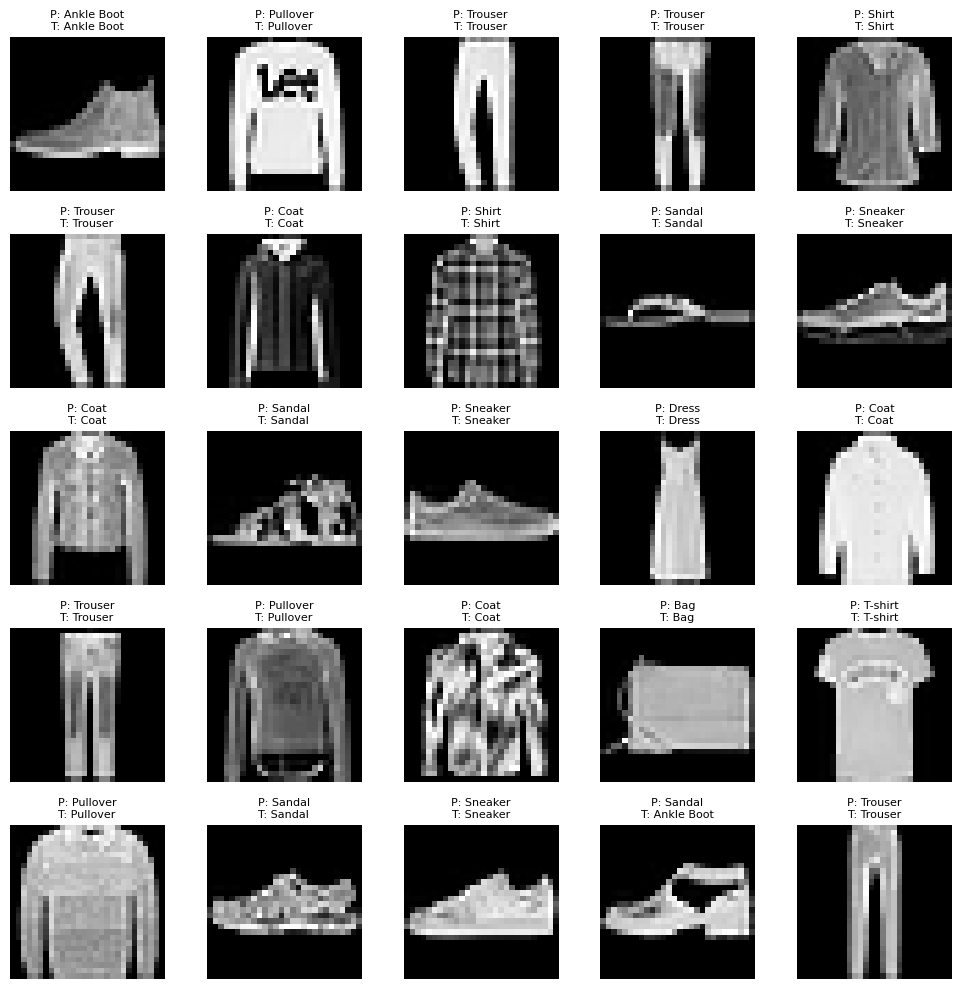

In [ ]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

plt.figure(figsize=(10,10))

for i in range(25):  # show 25 images
    plt.subplot(5,5,i+1)
    plt.imshow(test_images[i].reshape(28,28), cmap='gray')

    pred_label = class_names[predictions[i].argmax()]
    true_label = class_names[test_labels[i]]

    plt.title(f"P: {pred_label}\nT: {true_label}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate model
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


# Predictions
predictions = model.predict(test_images)

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

# Show 10 sample results
for i in range(10):
    print("\nImage", i)
    print("Actual Label   :", class_names[test_labels[i]])
    print("Predicted Label:", class_names[predictions[i].argmax()])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9179 - loss: 0.3772
Test Loss: 0.3772181272506714
Test Accuracy: 0.917900025844574
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

Image 0
Actual Label   : Ankle Boot
Predicted Label: Ankle Boot

Image 1
Actual Label   : Pullover
Predicted Label: Pullover

Image 2
Actual Label   : Trouser
Predicted Label: Trouser

Image 3
Actual Label   : Trouser
Predicted Label: Trouser

Image 4
Actual Label   : Shirt
Predicted Label: Shirt

Image 5
Actual Label   : Trouser
Predicted Label: Trouser

Image 6
Actual Label   : Coat
Predicted Label: Coat

Image 7
Actual Label   : Shirt
Predicted Label: Shirt

Image 8
Actual Label   : Sandal
Predicted Label: Sandal

Image 9
Actual Label   : Sneaker
Predicted Label: Sneaker
